In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
# ============================================================
# ÉTAPE 3 — CRÉATION DE LA VARIABLE CIBLE (LABELING)
# ============================================================

df_clean_capped = pd.read_csv('../data/processed/cleaned_data.csv')
df_labeled = df_clean_capped.copy()

print("Shape:", df_labeled.shape)
df_labeled.head()

Shape: (523844, 9)


,ERY,HK,LEUKO,HB,PLT,MCV,MCHC,MCH,RDW
0,4.5,40.7,8.5,13.7,154,90.4,33.7,30.4,13.2
1,4.2,36.8,11.8,12.9,255,87.4,35.1,30.6,12.7
2,4.3,37.4,8.5,12.7,310,86.4,33.9,29.3,13.0
3,4.3,36.4,7.7,13.3,221,84.4,36.6,30.9,13.1
4,4.1,37.1,10.8,12.3,198,91.3,33.2,30.3,13.5


In [ ]:
#Plages de référence médicales
normal_ranges = { 
    'ERY': (4.2, 5.8), 
    'HK': (37, 52), 
    'LEUKO': (4.0, 11.0), 
    'HB': (12, 17), 
    'PLT': (150, 400), 
    'MCV': (80, 100), 
    'MCHC': (32, 36), 
    'MCH': (27, 33), 
    'RDW': (11.5, 14.5) 
} 

df = pd.DataFrame(normal_ranges, index=['Borne basse', 'Borne haute']).T
print(df)

       Borne basse  Borne haute
ERY            4.2          5.8
HK            37.0         52.0
LEUKO          4.0         11.0
HB            12.0         17.0
PLT          150.0        400.0
MCV           80.0        100.0
MCHC          32.0         36.0
MCH           27.0         33.0
RDW           11.5         14.5


In [4]:
#Score simple
df_labeled['anomaly_score'] = 0

for col, (low, high) in normal_ranges.items():
    df_labeled['anomaly_score'] += (
        (df_labeled[col] < low) | (df_labeled[col] > high)
    ).astype(int)

print("Distribution du score simple (0 à 9):")
print(df_labeled['anomaly_score'].value_counts().sort_index())

Distribution du score simple (0 à 9):
anomaly_score
0    105997
1     81352
2     54502
3     66455
4     79311
5     62774
6     42215
7     21877
8      8191
9      1170
Name: count, dtype: int64


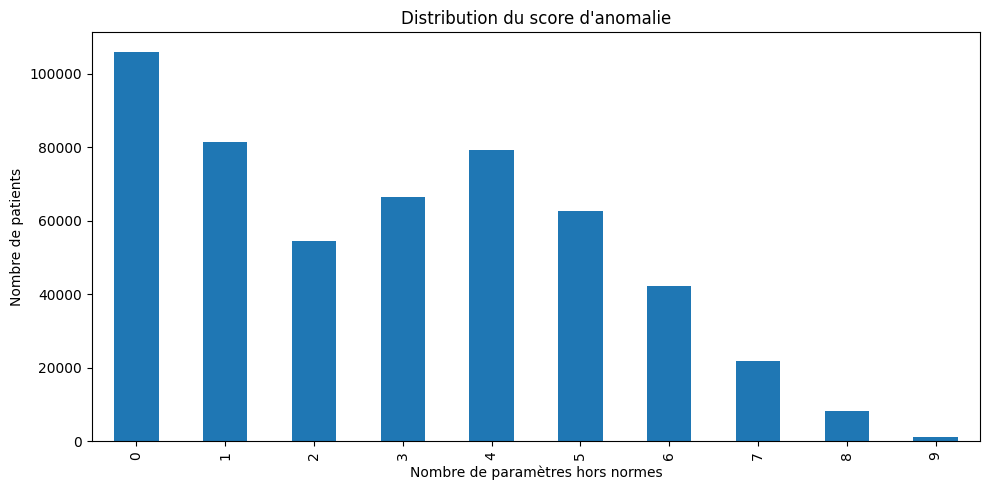

In [5]:
# Visualiser la distribution du score simple
plt.figure(figsize=(10, 5))
df_labeled['anomaly_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution du score d\'anomalie')
plt.xlabel('Nombre de paramètres hors normes')
plt.ylabel('Nombre de patients')
plt.tight_layout()
plt.savefig('../figures/distribution_anomaly_score.png', dpi=150)
plt.show()

In [6]:
#Score pondéré (sévérité médicale)
weights = {
    'ERY': 3,
    'HK': 1,
    'LEUKO': 3,
    'HB': 3,
    'PLT': 3,
    'MCV': 1,
    'MCHC': 1,
    'MCH': 1,
    'RDW': 1
}

df_labeled['weighted_score'] = 0
for col, (low, high) in normal_ranges.items():
    is_anomaly = ((df_labeled[col] < low) | (df_labeled[col] > high)).astype(int)
    df_labeled['weighted_score'] += is_anomaly * weights.get(col, 1)

print("Distribution du score pondéré (0 à 17):")
print(df_labeled['weighted_score'].value_counts().sort_index())

Distribution du score pondéré (0 à 17):
weighted_score
0     105997
1      36344
2      12182
3      49618
4      34499
5      16518
6      18386
7      50250
8      50127
9      21868
10     37498
11     36931
12     13730
13     16379
14     13180
15      4550
16      4617
17      1170
Name: count, dtype: int64


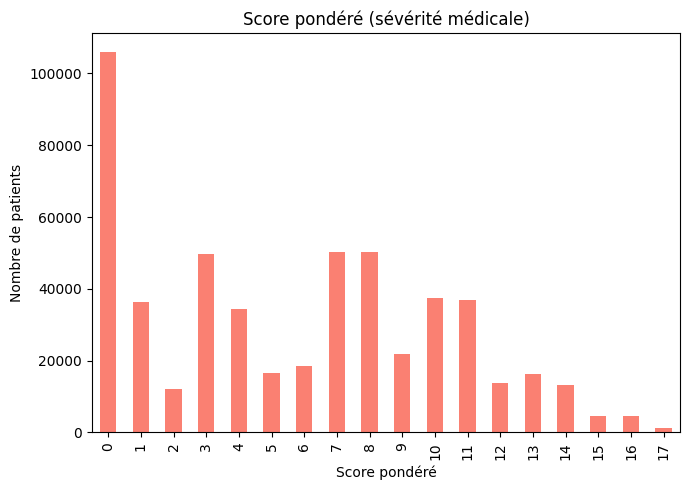

In [8]:
# Visualiser la distribution du score pondéré
plt.figure(figsize=(7, 5))
df_labeled['weighted_score'].value_counts().sort_index().plot(kind='bar', color='salmon')
plt.title('Score pondéré (sévérité médicale)')
plt.xlabel('Score pondéré')
plt.ylabel('Nombre de patients')
plt.tight_layout()
plt.savefig('../figures/distribution_score_pondere.png', dpi=150)
plt.show()

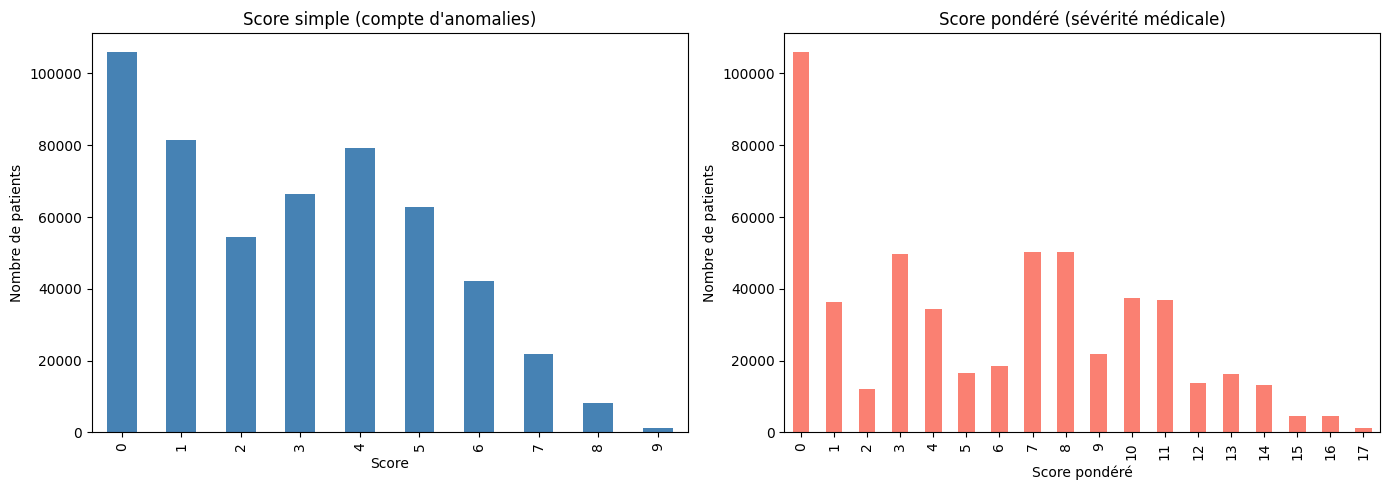

In [ ]:
# Comparer les distributions des deux scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_labeled['anomaly_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Score simple (compte d'anomalies)")
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Nombre de patients')

df_labeled['weighted_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Score pondéré (sévérité médicale)')
axes[1].set_xlabel('Score pondéré')
axes[1].set_ylabel('Nombre de patients')

plt.tight_layout()
plt.savefig('../figures/distribution_scores.png', dpi=150)
plt.show()

In [9]:
print("-- Score simple (anomaly_score) --")
for threshold in range(1, 10):
    label_temp = (df_labeled['anomaly_score'] >= threshold).astype(int)
    pct_anomaly = label_temp.mean() * 100
    print(f"Seuil >= {threshold} : {label_temp.sum()} anomalies / "
          f"{len(label_temp)} ({pct_anomaly:.2f}%) | Normal: {100-pct_anomaly:.2f}%")

-- Score simple (anomaly_score) --
Seuil >= 1 : 417847 anomalies / 523844 (79.77%) | Normal: 20.23%
Seuil >= 2 : 336495 anomalies / 523844 (64.24%) | Normal: 35.76%
Seuil >= 3 : 281993 anomalies / 523844 (53.83%) | Normal: 46.17%
Seuil >= 4 : 215538 anomalies / 523844 (41.15%) | Normal: 58.85%
Seuil >= 5 : 136227 anomalies / 523844 (26.01%) | Normal: 73.99%
Seuil >= 6 : 73453 anomalies / 523844 (14.02%) | Normal: 85.98%
Seuil >= 7 : 31238 anomalies / 523844 (5.96%) | Normal: 94.04%
Seuil >= 8 : 9361 anomalies / 523844 (1.79%) | Normal: 98.21%
Seuil >= 9 : 1170 anomalies / 523844 (0.22%) | Normal: 99.78%


In [10]:
print("-- Score pondéré (weighted_score) --")
max_w = int(df_labeled['weighted_score'].max())
for threshold in range(1, max_w + 1):
    label_temp = (df_labeled['weighted_score'] >= threshold).astype(int)
    pct_anomaly = label_temp.mean() * 100
    print(f"Seuil >= {threshold} : {label_temp.sum()} anomalies / "
          f"{len(label_temp)} ({pct_anomaly:.2f}%) | Normal: {100-pct_anomaly:.2f}%")

-- Score pondéré (weighted_score) --
Seuil >= 1 : 417847 anomalies / 523844 (79.77%) | Normal: 20.23%
Seuil >= 2 : 381503 anomalies / 523844 (72.83%) | Normal: 27.17%
Seuil >= 3 : 369321 anomalies / 523844 (70.50%) | Normal: 29.50%
Seuil >= 4 : 319703 anomalies / 523844 (61.03%) | Normal: 38.97%
Seuil >= 5 : 285204 anomalies / 523844 (54.44%) | Normal: 45.56%
Seuil >= 6 : 268686 anomalies / 523844 (51.29%) | Normal: 48.71%
Seuil >= 7 : 250300 anomalies / 523844 (47.78%) | Normal: 52.22%
Seuil >= 8 : 200050 anomalies / 523844 (38.19%) | Normal: 61.81%
Seuil >= 9 : 149923 anomalies / 523844 (28.62%) | Normal: 71.38%
Seuil >= 10 : 128055 anomalies / 523844 (24.45%) | Normal: 75.55%
Seuil >= 11 : 90557 anomalies / 523844 (17.29%) | Normal: 82.71%
Seuil >= 12 : 53626 anomalies / 523844 (10.24%) | Normal: 89.76%
Seuil >= 13 : 39896 anomalies / 523844 (7.62%) | Normal: 92.38%
Seuil >= 14 : 23517 anomalies / 523844 (4.49%) | Normal: 95.51%
Seuil >= 15 : 10337 anomalies / 523844 (1.97%) | Norma

## Choix du seuil final

**Seuil retenu : `weighted_score >= 9`**

Justification :
- Ratio obtenu : ~28.6% anomalies / ~71.4% normal — équilibre de classes favorable à l'entraînement des modèles, sans nécessiter de technique de rééquilibrage (SMOTE, class_weight, etc.)
- Un score pondéré ≥9 (sur un maximum de 17) correspond cliniquement à une déviation significative sur au moins 3 paramètres majeurs (3×3=9), ou une combinaison équivalente de paramètres majeurs et secondaires
- Ce seuil est cohérent avec les seuils testés précédemment sur le score simple (le seuil ≥4 sur 9, qui donnait un ratio comparable ~31.6%/68.4%)
- Un seuil trop bas (≥1, ≥2) capture des déviations mineures et isolées, peu représentatives d'une véritable anomalie clinique ; un seuil trop élevé (≥15, ≥16) produit un déséquilibre de classes sévère, peu exploitable en ML

In [ ]:
THRESHOLD = 9

df_labeled['label'] = (df_labeled['weighted_score'] >= THRESHOLD).astype(int)

print(f"Seuil retenu (weighted_score >= {THRESHOLD})")
print(df_labeled['label'].value_counts())
print(f"\nProportion d'anomalies: {df_labeled['label'].mean()*100:.2f}%")
print(f"Proportion normale: {(1 - df_labeled['label'].mean())*100:.2f}%")

Seuil retenu (weighted_score >= 9)
label
0    373921
1    149923
Name: count, dtype: int64

Proportion d'anomalies: 28.62%
Proportion normale: 71.38%


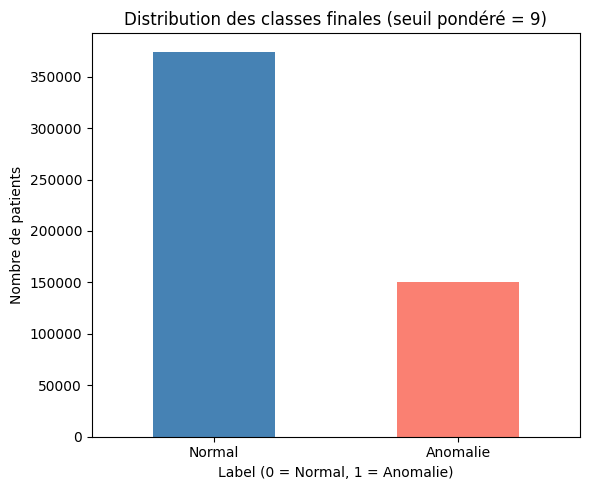

In [14]:
plt.figure(figsize=(6, 5))
df_labeled['label'].value_counts().sort_index().plot(
    kind='bar', color=['steelblue', 'salmon'])
plt.title(f'Distribution des classes finales (seuil pondéré = {THRESHOLD})')
plt.xlabel('Label (0 = Normal, 1 = Anomalie)')
plt.ylabel('Nombre de patients')
plt.xticks([0, 1], ['Normal', 'Anomalie'], rotation=0)
plt.tight_layout()
plt.savefig('../figures/distribution_classes_finales.png', dpi=150)
plt.show()

In [15]:
df_labeled.to_csv('../data/processed/labeled_data.csv', index=False)
print("✅ Dataset avec labels sauvegardé dans data/processed/labeled_data.csv")
df_labeled.head()

✅ Dataset avec labels sauvegardé dans data/processed/labeled_data.csv


,ERY,HK,LEUKO,HB,PLT,MCV,MCHC,MCH,RDW,anomaly_score,weighted_score,label
0,4.5,40.7,8.5,13.7,154,90.4,33.7,30.4,13.2,0,0,0
1,4.2,36.8,11.8,12.9,255,87.4,35.1,30.6,12.7,2,4,0
2,4.3,37.4,8.5,12.7,310,86.4,33.9,29.3,13.0,0,0,0
3,4.3,36.4,7.7,13.3,221,84.4,36.6,30.9,13.1,2,2,0
4,4.1,37.1,10.8,12.3,198,91.3,33.2,30.3,13.5,1,3,0


## Note méthodologique — Data leakage

Les colonnes `anomaly_score` et `weighted_score` ont servi directement à la création du label. Elles **ne doivent jamais** être utilisées comme features d'entrée pour les modèles (étape 4). Les 9 variables CBC brutes (ERY, HK, LEUKO, HB, PLT, MCV, MCHC, MCH, RDW) seront conservées comme features ; ce choix méthodologique (Option A, conservation de toutes les variables) sera documenté explicitement dans le rapport final.